In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print(f"TensorFlow Version: {tf.__version__}")

2026-01-08 02:51:10.501569: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-01-08 02:51:10.914235: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-01-08 02:51:10.916641: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-08 02:51:12.115109: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


TensorFlow Version: 2.13.1


In [2]:
# Load dataset
df = pd.read_csv('smart_traffic_dataset.csv')

# Display first few rows to verify
print("First 5 rows of data:")
display(df.head())

# Basic statistics
print("\nData Statistics:")
display(df.describe())

First 5 rows of data:


,Current_Occupancy,Queue_Main_In,Queue_Entrance,Queue_Main_Out,Green_T1,Green_T2,Green_T3
0,49,1,0,24,10,58,11
1,33,23,7,6,57,13,16
2,31,22,4,15,48,31,10
3,49,17,17,19,10,59,10
4,19,11,18,22,20,37,29



Data Statistics:


,Current_Occupancy,Queue_Main_In,Queue_Entrance,Queue_Main_Out,Green_T1,Green_T2,Green_T3
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,32.339600,15.186400,9.973600,14.891400,23.318600,44.499200,18.001800
std,19.200604,8.967415,6.016456,9.065409,16.207333,17.756967,11.688863
min,0.000000,0.000000,0.000000,0.000000,10.000000,10.000000,10.000000
25%,16.000000,7.000000,5.000000,7.000000,10.000000,30.000000,10.000000
50%,32.000000,15.000000,10.000000,15.000000,12.000000,56.000000,12.000000
75%,49.000000,23.000000,15.000000,23.000000,36.000000,60.000000,23.000000
max,65.000000,30.000000,20.000000,30.000000,60.000000,60.000000,60.000000


In [3]:
# 1. Separate Features (Inputs) and Labels (Outputs)
X = df[['Current_Occupancy', 'Queue_Main_In', 'Queue_Entrance', 'Queue_Main_Out']]
y = df[['Green_T1', 'Green_T2', 'Green_T3']]

# 2. Split into Training (80%) and Testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Scale the data (Normalization)
# We save the scalers because we need them later to predict on real data
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

y_train_scaled = scaler_y.fit_transform(y_train)
y_test_scaled = scaler_y.transform(y_test)

print(f"Training shapes: X={X_train_scaled.shape}, y={y_train_scaled.shape}")

Training shapes: X=(4000, 4), y=(4000, 3)


In [4]:
model = keras.Sequential([
    # Input Layer (4 inputs) -> Hidden Layer 1 (64 neurons, ReLU activation)
    layers.Dense(64, activation='relu', input_shape=[4]),
    
    # Hidden Layer 2 (32 neurons, ReLU activation)
    layers.Dense(32, activation='relu'),
    
    # Output Layer (3 outputs for the 3 Green Times)
    # We use 'linear' activation because we are predicting continuous numbers (regression)
    layers.Dense(3) 
])

# Compile the model
# Optimizer: Adam (Standard for most problems)
# Loss: MSE (Mean Squared Error) - good for regression
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae'] # Mean Absolute Error (easy to understand)
)

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 64)                320       
                                                                 
 dense_1 (Dense)             (None, 32)                2080      
                                                                 
 dense_2 (Dense)             (None, 3)                 99        
                                                                 
Total params: 2499 (9.76 KB)
Trainable params: 2499 (9.76 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


2026-01-08 02:51:57.164406: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-01-08 02:51:57.400596: W tensorflow/core/common_runtime/gpu/gpu_device.cc:1960] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [5]:
history = model.fit(
    X_train_scaled, y_train_scaled,
    validation_split=0.2, # Use 20% of training data to validate during training
    batch_size=32,
    epochs=100,
    verbose=1
)

Epoch 1/100
100/100 [==============================] - 1s 2ms/step - loss: 0.1009 - mae: 0.2341 - val_loss: 0.0436 - val_mae: 0.1599
Epoch 2/100
100/100 [==============================] - 0s 1ms/step - loss: 0.0317 - mae: 0.1323 - val_loss: 0.0258 - val_mae: 0.1174
Epoch 3/100
100/100 [==============================] - 0s 2ms/step - loss: 0.0217 - mae: 0.1044 - val_loss: 0.0193 - val_mae: 0.0980
Epoch 4/100
100/100 [==============================] - 0s 2ms/step - loss: 0.0173 - mae: 0.0901 - val_loss: 0.0156 - val_mae: 0.0854
Epoch 5/100
100/100 [==============================] - 0s 2ms/step - loss: 0.0146 - mae: 0.0813 - val_loss: 0.0131 - val_mae: 0.0769
Epoch 6/100
100/100 [==============================] - 0s 1ms/step - loss: 0.0124 - mae: 0.0727 - val_loss: 0.0118 - val_mae: 0.0711
Epoch 7/100
100/100 [==============================] - 0s 1ms/step - loss: 0.0108 - mae: 0.0664 - val_loss: 0.0098 - val_mae: 0.0625
Epoch 8/100
100/100 [==============================] - 0s 1ms/step - 

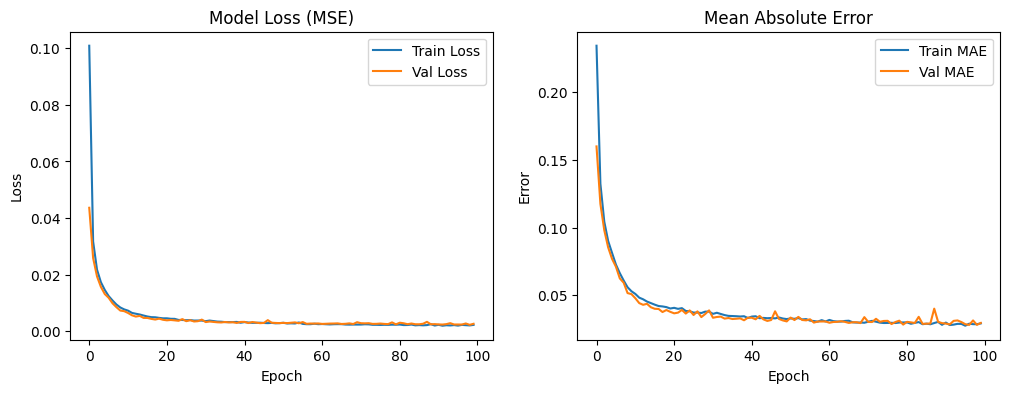

In [6]:
plt.figure(figsize=(12, 4))

# Plot Loss (MSE)
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss (MSE)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plot MAE
plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Val MAE')
plt.title('Mean Absolute Error')
plt.xlabel('Epoch')
plt.ylabel('Error')
plt.legend()

plt.show()

In [7]:
# Function to predict new values
def predict_traffic_lights(current_occupancy, q_main_in, q_entrance, q_main_out):
    # 1. Prepare input array
    input_data = np.array([[current_occupancy, q_main_in, q_entrance, q_main_out]])
    
    # 2. Scale input
    input_scaled = scaler_X.transform(input_data)
    
    # 3. Predict
    prediction_scaled = model.predict(input_scaled)
    
    # 4. Inverse scale (convert back to real seconds)
    prediction = scaler_y.inverse_transform(prediction_scaled)
    
    return prediction[0]

# --- SCENARIO 1: Road is Overcrowded (Occupancy > 36) ---
# Expectation: T2 (Exit) should be high, T1 & T3 (Entries) should be low
occ = 50 
q_in = 10
q_ent = 10
q_out = 20

res = predict_traffic_lights(occ, q_in, q_ent, q_out)
print(f"--- Scenario: Overcrowded (Occupancy: {occ}) ---")
print(f"T1 Green (Main Start): {res[0]:.1f} sec")
print(f"T2 Green (Main End):   {res[1]:.1f} sec  <-- Should be HIGH")
print(f"T3 Green (Entrance):   {res[2]:.1f} sec")

# --- SCENARIO 2: Road is Empty, High Queue at Entrance ---
# Expectation: T3 (Entrance) should be high
occ = 10 
q_in = 5
q_ent = 25
q_out = 5

res = predict_traffic_lights(occ, q_in, q_ent, q_out)
print(f"\n--- Scenario: Empty Road, High Entrance Traffic ---")
print(f"T1 Green (Main Start): {res[0]:.1f} sec")
print(f"T2 Green (Main End):   {res[1]:.1f} sec")
print(f"T3 Green (Entrance):   {res[2]:.1f} sec <-- Should be HIGH")

1/1 [==============================] - 0s 55ms/step
--- Scenario: Overcrowded (Occupancy: 50) ---
T1 Green (Main Start): 10.7 sec
T2 Green (Main End):   59.7 sec  <-- Should be HIGH
T3 Green (Entrance):   10.4 sec
1/1 [==============================] - 0s 13ms/step

--- Scenario: Empty Road, High Entrance Traffic ---
T1 Green (Main Start): 15.5 sec
T2 Green (Main End):   14.9 sec
T3 Green (Entrance):   55.5 sec <-- Should be HIGH


/home/kareem/.local/lib/python3.8/site-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/home/kareem/.local/lib/python3.8/site-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


In [8]:
# Save the Keras model
model.save('traffic_ai_model.h5')

# Save the scalers (using pickle) so we can scale inputs correctly in the future
import joblib
joblib.dump(scaler_X, 'scaler_X.pkl')
joblib.dump(scaler_y, 'scaler_y.pkl')

print("Model and Scalers saved successfully!")

Model and Scalers saved successfully!


/home/kareem/.local/lib/python3.8/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


32/32 [==============================] - 0s 1ms/step
Model Accuracy (R2 Score): 96.48%
Average Error (MAE):       1.54 seconds


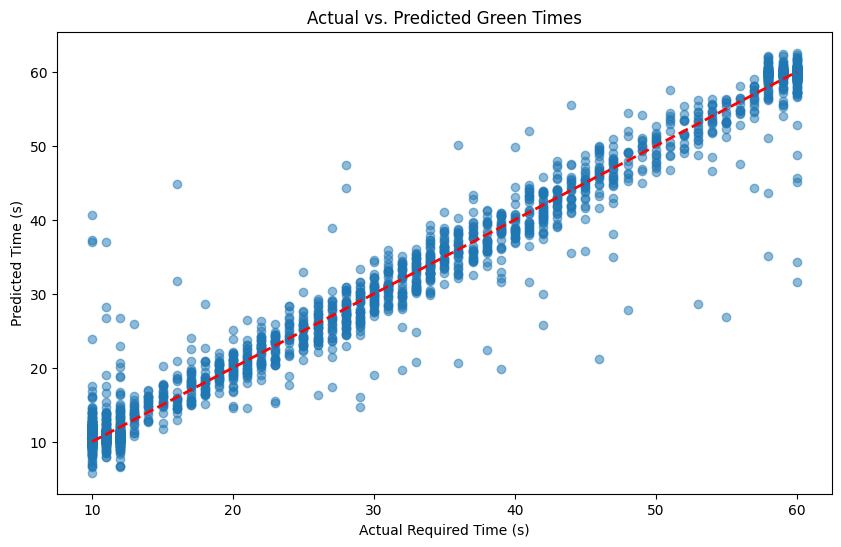

In [9]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# 1. Get predictions on the test set
predictions_scaled = model.predict(X_test_scaled)

# 2. Convert scaled predictions back to real seconds
predictions_real = scaler_y.inverse_transform(predictions_scaled)
y_test_real = scaler_y.inverse_transform(y_test_scaled)

# 3. Calculate R-Squared (The "Accuracy" Score)
r2 = r2_score(y_test_real, predictions_real)
print(f"Model Accuracy (R2 Score): {r2 * 100:.2f}%")

# 4. Calculate Average Error (MAE)
mae = mean_absolute_error(y_test_real, predictions_real)
print(f"Average Error (MAE):       {mae:.2f} seconds")

# 5. Visual Check: Actual vs Predicted Plot
plt.figure(figsize=(10, 6))
plt.scatter(y_test_real, predictions_real, alpha=0.5)
plt.plot([y_test_real.min(), y_test_real.max()], [y_test_real.min(), y_test_real.max()], 'r--', lw=2)
plt.xlabel('Actual Required Time (s)')
plt.ylabel('Predicted Time (s)')
plt.title('Actual vs. Predicted Green Times')
plt.show()